# Regression

Beyond classification, we may be interested in learning a regression.
This usually means that our output is a real (often continuous) value, which represents a quantity of interest (think about a band gap, an energy, a mechanical property etc.)
In this notebook, we will explore how to perform simple regression and classification methods using materials datasets

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install dscribe
    !pip install umap-learn
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/05-BasicLearning"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# ase is the package we use to read files related to atomistic structures
from ase import Atoms
from ase.io import read

# we will import the dimensionality reduction and clustering algorithms as well
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn import metrics

# dscribe is one package that is widely used for featurization of atomistic structures
from dscribe.descriptors import SOAP

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Building intuition of linear regression with a sample dataset

Just like before, we will demonstrate what do we mean by performing a regression using the periodic table dataset and using a few linear models.
Specifically, we will look into the relationship between the electronegativity and the first ionization energy, which we demonstrated in the first lecture:

In [3]:
pt = pd.read_csv(f"{ROOT}/data/ptable.csv")
df = pt.loc[
    (~pt["Electronegativity"].isna())
    & (~pt["FirstIonization"].isna())
]

Now, let's take two properties that we know are related:

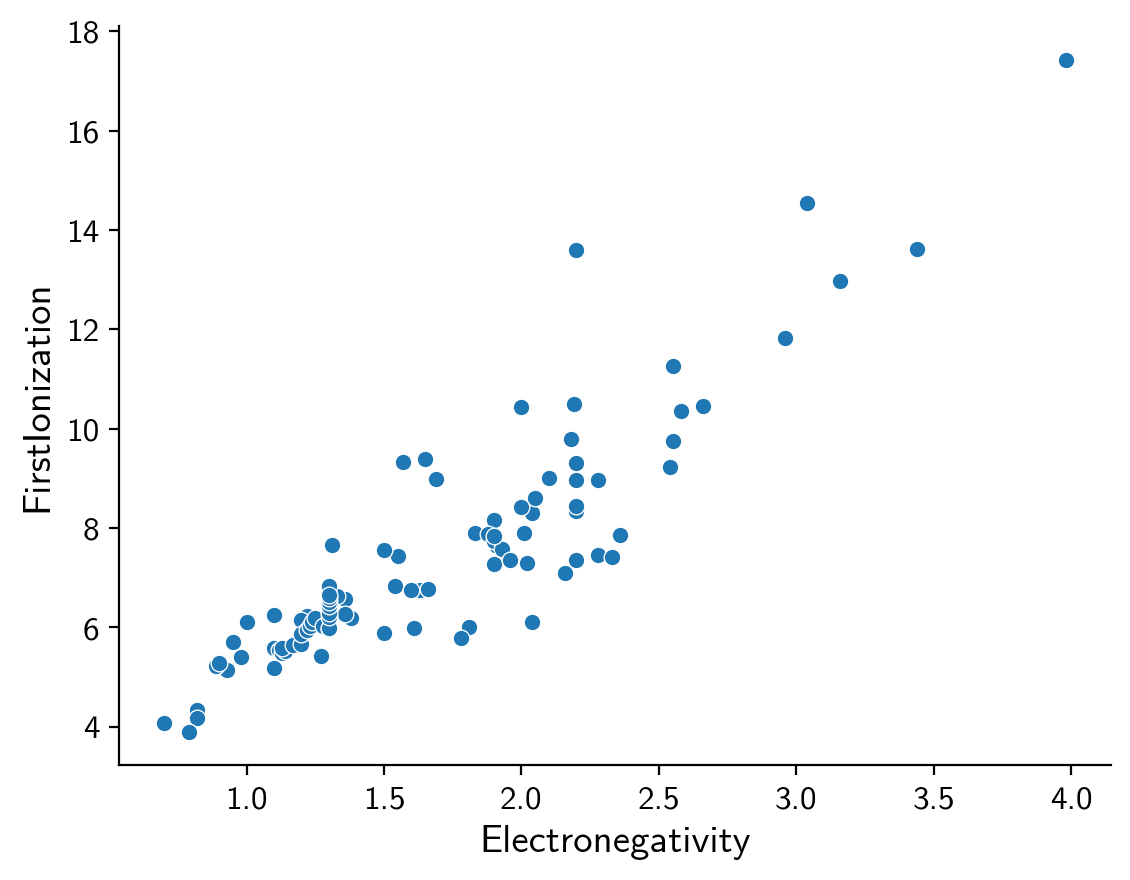

In [4]:
ax = sns.scatterplot(
    data=df,
    y="FirstIonization",
    x="Electronegativity",
)
plt.show()

## Creating a linear regression model

Creating a linear regression model is relatively straightforward. 
We can use `scikit-learn`'s off-the-shelf model to fit a linear regression, and discuss the results later.
Let's create the dataset and the model:

In [5]:
X = df["Electronegativity"].values.reshape(-1, 1)
y = df["FirstIonization"].values.reshape(-1)

model = LinearRegression()
model.fit(X, y)

LinearRegression()

This was very easy. Let's look at the results:

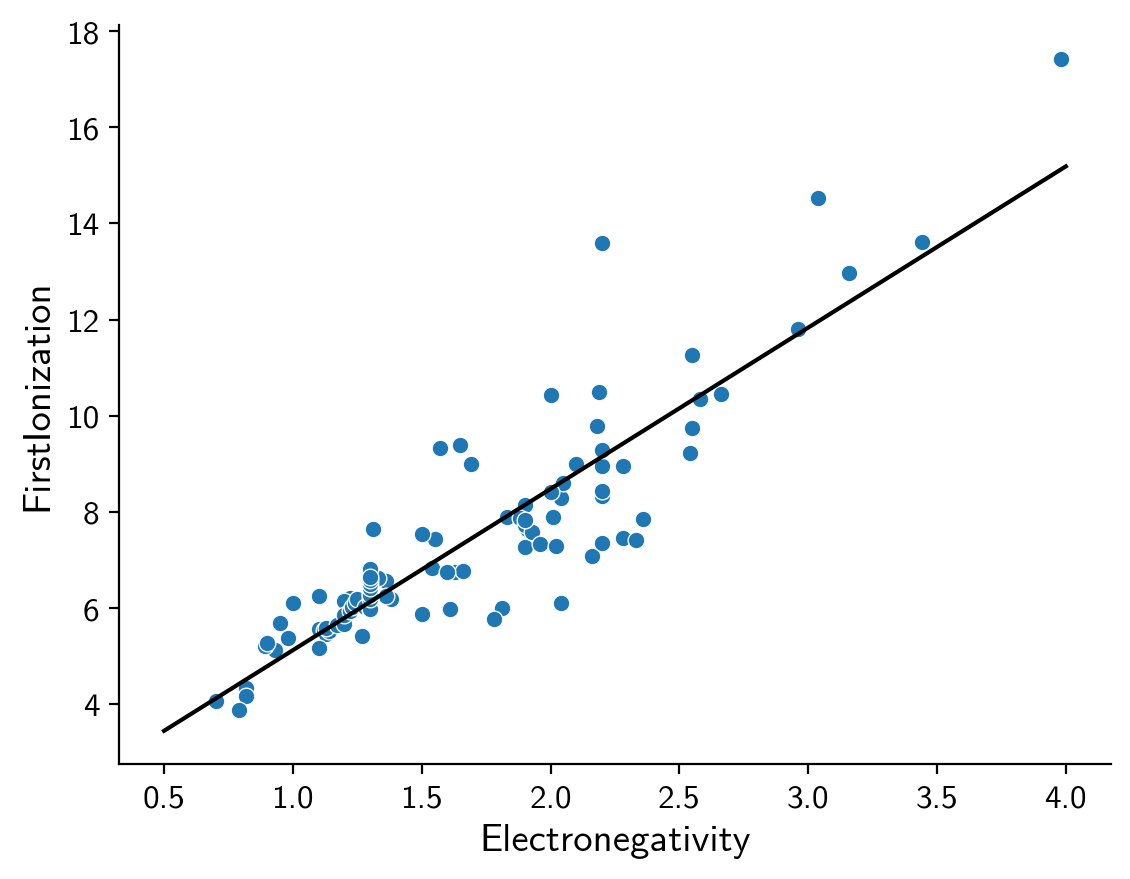

In [6]:
ax = sns.scatterplot(
    data=df,
    y="FirstIonization",
    x="Electronegativity",
)

_x = np.linspace(0.5, 4)

ax.plot(_x, model.predict(_x.reshape(-1, 1)), "k-")

plt.show()

Now, we have an equation that relates the first ionization energy and the electronegativity, which is encoded into the "model" object:

In [7]:
print(f"E_I = {model.coef_[0]:.2f} * χ + {model.intercept_:.2f}")

E_I = 3.35 * χ + 1.78


## Analyzing the linear regression

One useful thing to realize in model performance is that we often want to visualize not the variation of the two quantities, but rather how far off from the true values is our prediction.
In the ML literature, you often see the so-called parity plot.
It shows the relationship between true values and predicted values

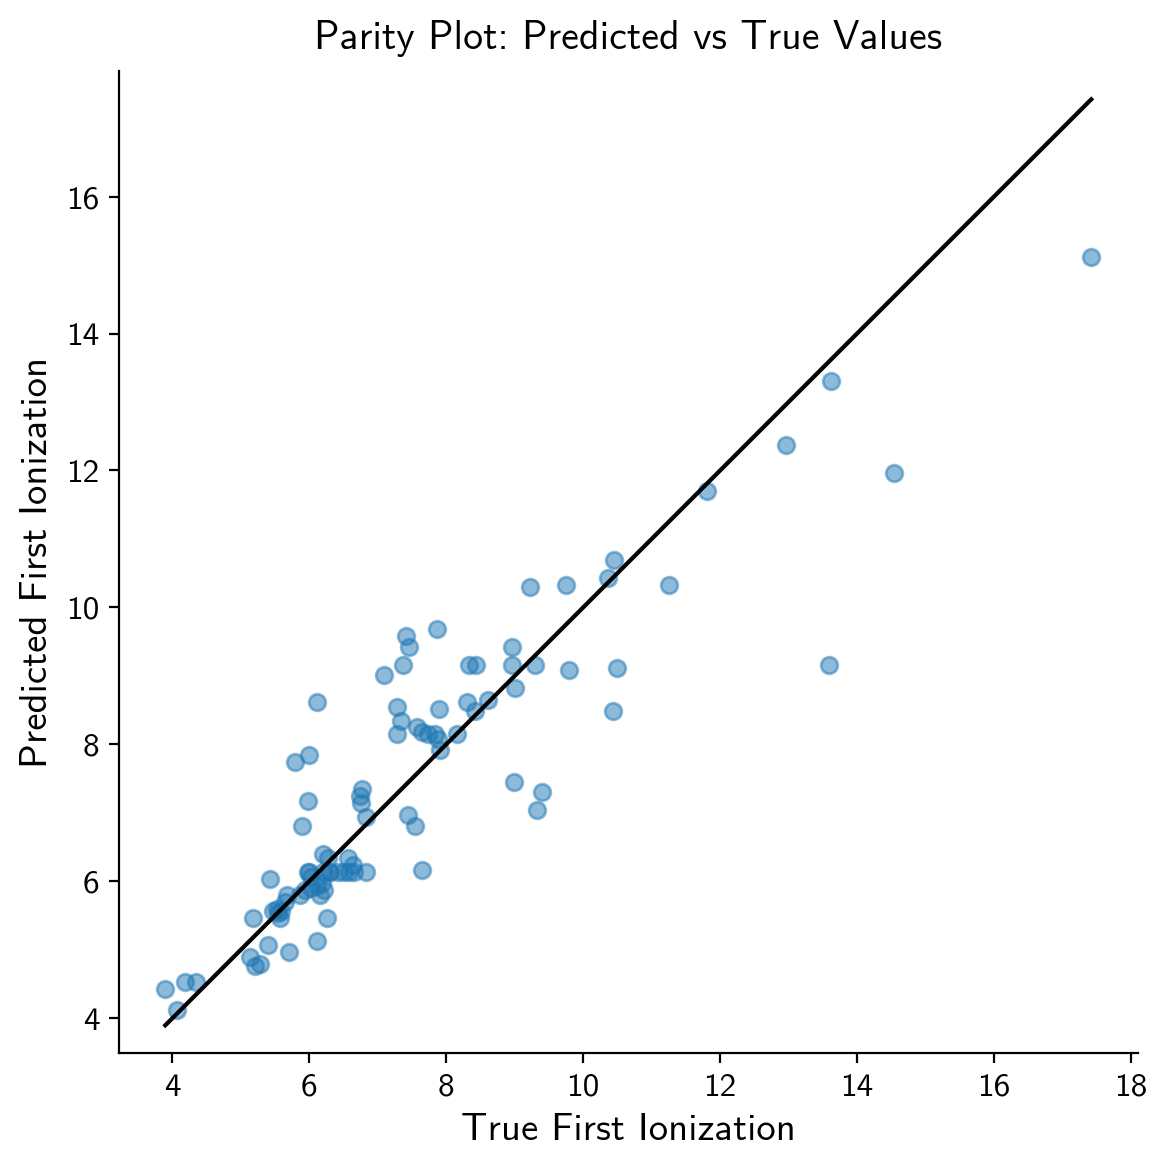

In [8]:
# Create parity plots to compare predicted vs actual values
fig, ax = plt.subplots(figsize=(6, 6))
y_pred = model.predict(X)
ax.scatter(y, y_pred, alpha=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "k-", label="Perfect prediction")
ax.set_xlabel("True First Ionization")
ax.set_ylabel("Predicted First Ionization")
ax.set_title("Parity Plot: Predicted vs True Values")
# ax.legend()
ax.axis("equal")
fig.tight_layout()
plt.show()

## Robustness to training set choices

Now, we can ask ourselves what would happen if we had a training set.
Do we expect linear regression to change substantially if we had one?
Let's make a numerical experiment for that:

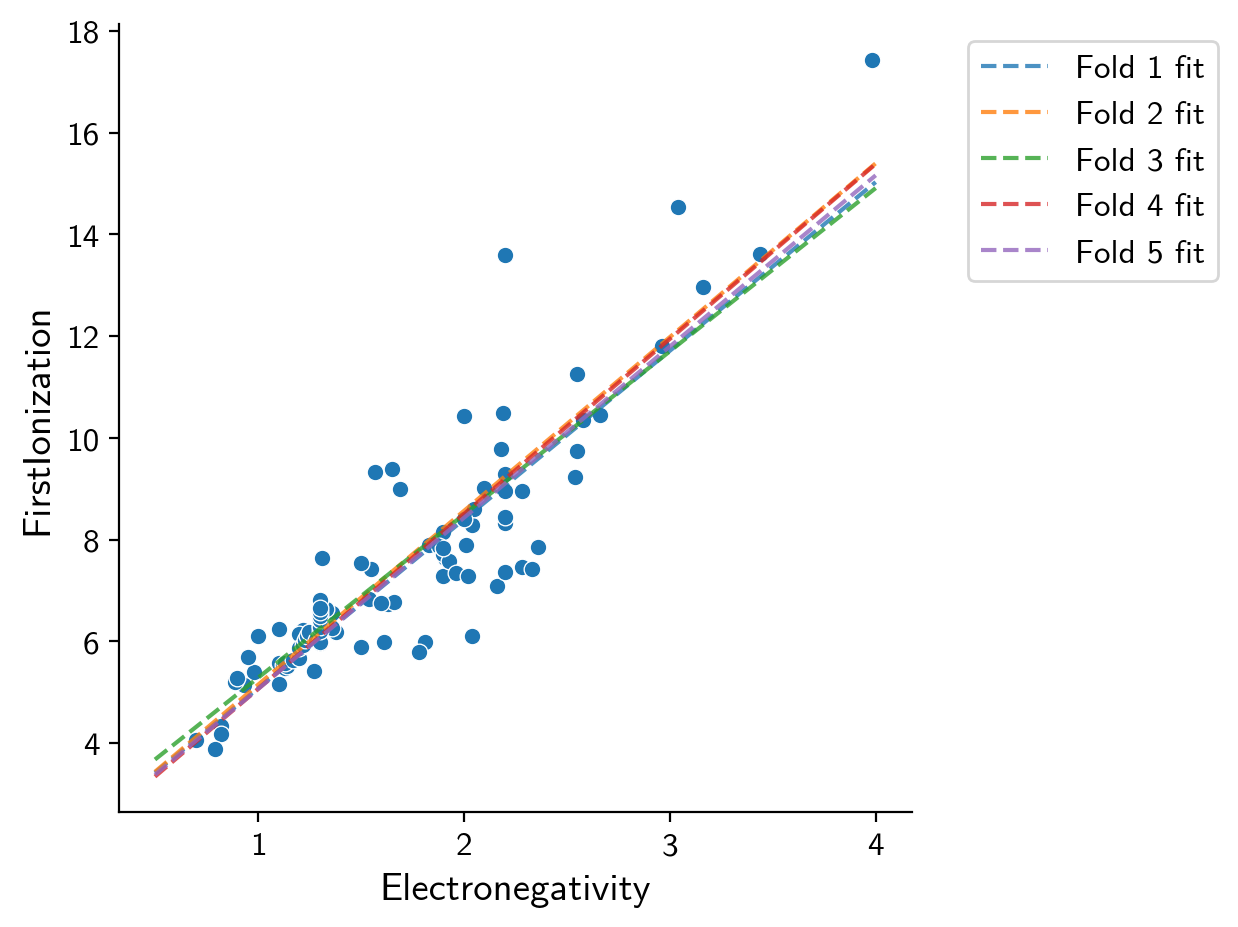

In [9]:
# Create K-fold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics for each fold
r2_scores = []
mse_scores = []

ax = sns.scatterplot(
    data=df,
    y="FirstIonization",
    x="Electronegativity",
)

# Plot different fits from cross-validation
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Fit model on training data
    fold_model = LinearRegression()
    fold_model.fit(X_train, y_train)

    # Plot this fold's fit
    ax.plot(
        _x,
        fold_model.predict(_x.reshape(-1, 1)),
        "--",
        alpha=0.8,
        label=f"Fold {fold+1} fit",
    )

    # Calculate metrics
    y_pred = fold_model.predict(X_val)
    r2_scores.append(metrics.r2_score(y_val, y_pred))
    mse_scores.append(metrics.mean_squared_error(y_val, y_pred))

# Add legend and show metrics
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In this example, it seems that it does not vary that much.
Sometimes, however, a small change in the choice of the training set may lead to very different results.
Make sure you always visualize and think about your data!

For instance, let's look at our metrics:

In [10]:
print("\nCross-validation results:")
print(f"Mean R² score: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")


Cross-validation results:
Mean R² score: 0.766 ± 0.073
Mean MSE: 1.117 ± 0.432


You see how the results can vary quite a lot just by changing the data splits?

## Polynomial regression

One method that is related to linear regression is the idea of polynomial regression.

Instead of fitting parameters to a linear model, you can find the parameters $c_i$ of a polynomial of the following type:

$$
y = \sum_{n=0}^N c_i x^n
$$

This set of parameters can express much more complex relationships between the data points, and is versatile for solving many problems.

Let's explore these for the solubility dataset.

In [11]:
df = pd.read_csv(f"{ROOT}/data/solubility.csv")

In [12]:
features = [
    'MolWt', 'HeavyAtomCount',
    'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
    'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
    'NumAliphaticRings', 'RingCount',
#     'TPSA', 'LabuteASA', 'BalabanJ',
#     'BertzCT'
]

Creating the features...

In [13]:
idx = df[features].dropna().index

X = df[features].loc[idx].values
X = (X - X.mean(0)) / X.std(0)

y = df["Solubility"].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=77)

print(X_train.shape, X_test.shape)

(7985, 11) (1997, 11)


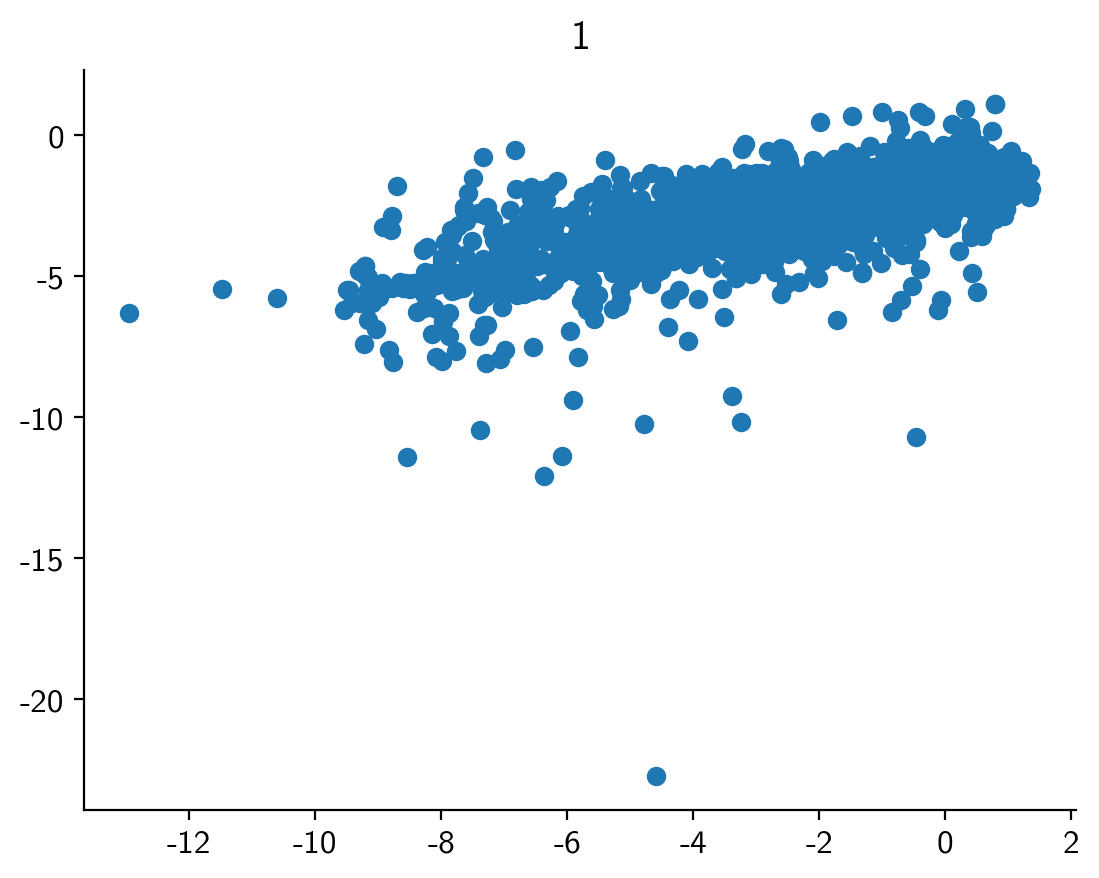

R² score for degree 1: 0.400


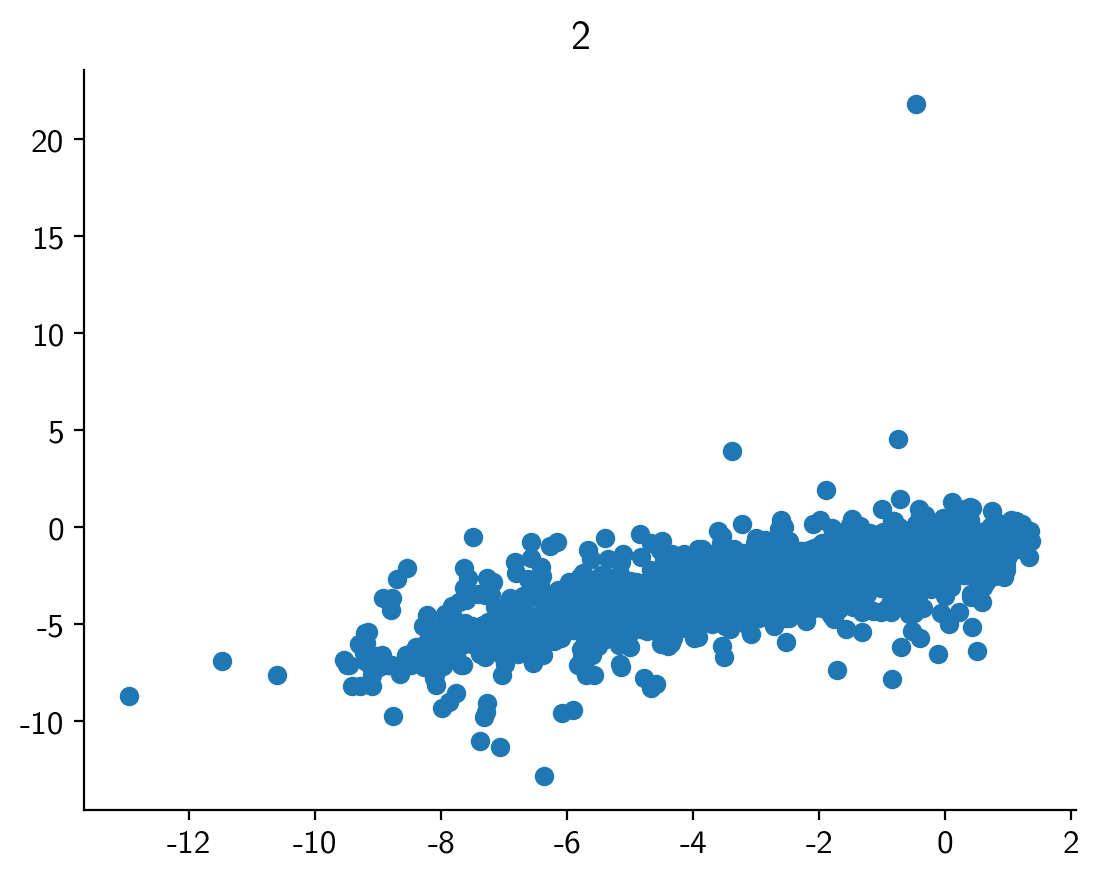

R² score for degree 2: 0.499


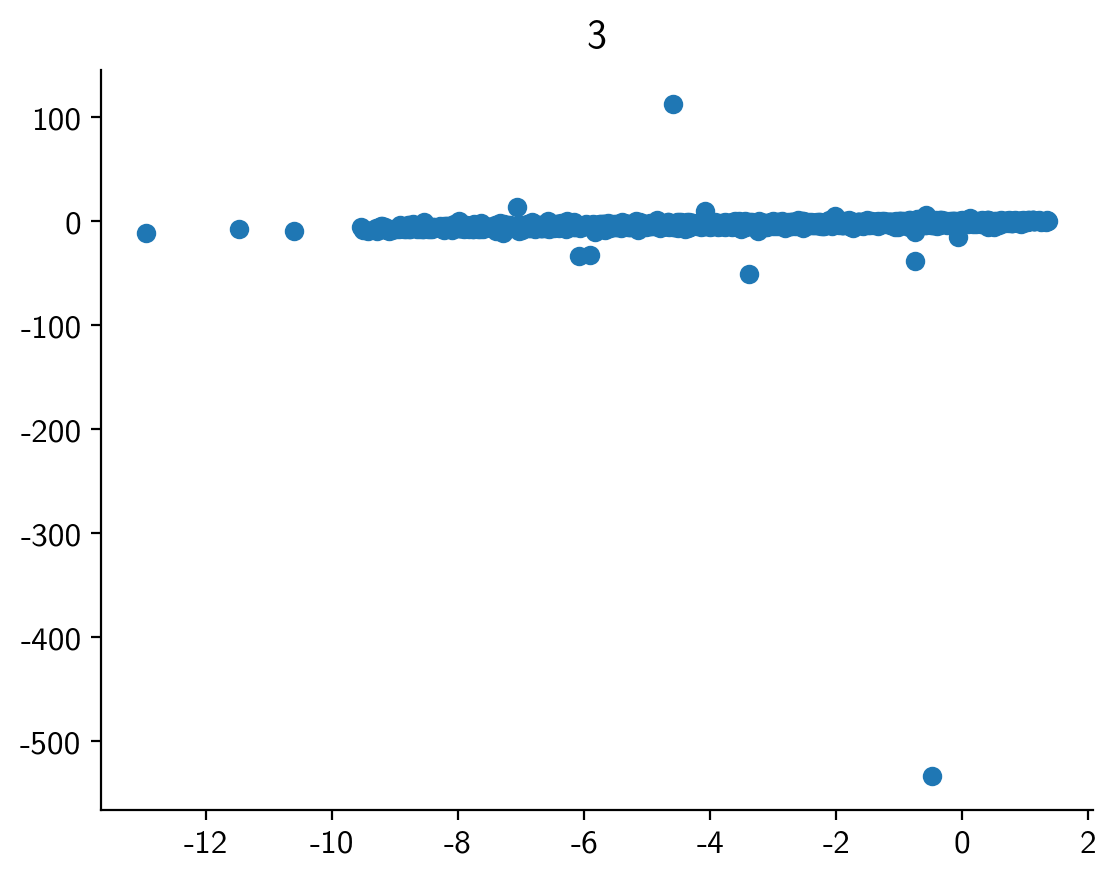

R² score for degree 3: -26.044


In [18]:
# Create polynomial features
degrees = [1, 2, 3] 

for i, degree in enumerate(degrees):
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.fit_transform(X_test)

    # Fit polynomial regression
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    # Calculate and print R² score
    y_pred = poly_model.predict(X_test_poly)
    
    fig, ax = plt.subplots()
    
    ax.scatter(y_test, y_pred)
    ax.set_title(degree)
#     ax.set_xlim(-10, 5)
#     ax.set_ylim(-10, 5)
    plt.show()
    
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"R² score for degree {degree}: {r2:.3f}")

Can you explain why the model with degree 3 is worse than the model with degree 2?